# Chapter 8 Sending Information to Servers

## 1. How Forms Work

## 2. Rendering Widgets

✅ 생성된 InputLayout 객체 수: 3개
 - [input ] 위치: (x= 60, y=21.75) | 크기: 200px x 18px
 - [input ] 위치: (x= 85, y=44.25) | 크기: 200px x 18px
 - [button] 위치: (x= 13, y=66.75) | 크기: 200px x 18px

✅ 렌더링된 사각형(DrawRect): 3개
 - [lightblue ] 위치: (60, 21.75) | 크기: 200px x 18px
 - [lightblue ] 위치: (85, 44.25) | 크기: 200px x 18px
 - [orange    ] 위치: (13, 66.75) | 크기: 200px x 18px

✅ 렌더링된 텍스트(DrawText): 5개
 - 'Name:' (x=13, y=21.75)
 - '1' (x=60, y=21.75)
 - 'Comment:' (x=13, y=44.25)
 - '2' (x=85, y=44.25)
 - 'Submit!' (x=13, y=66.75)


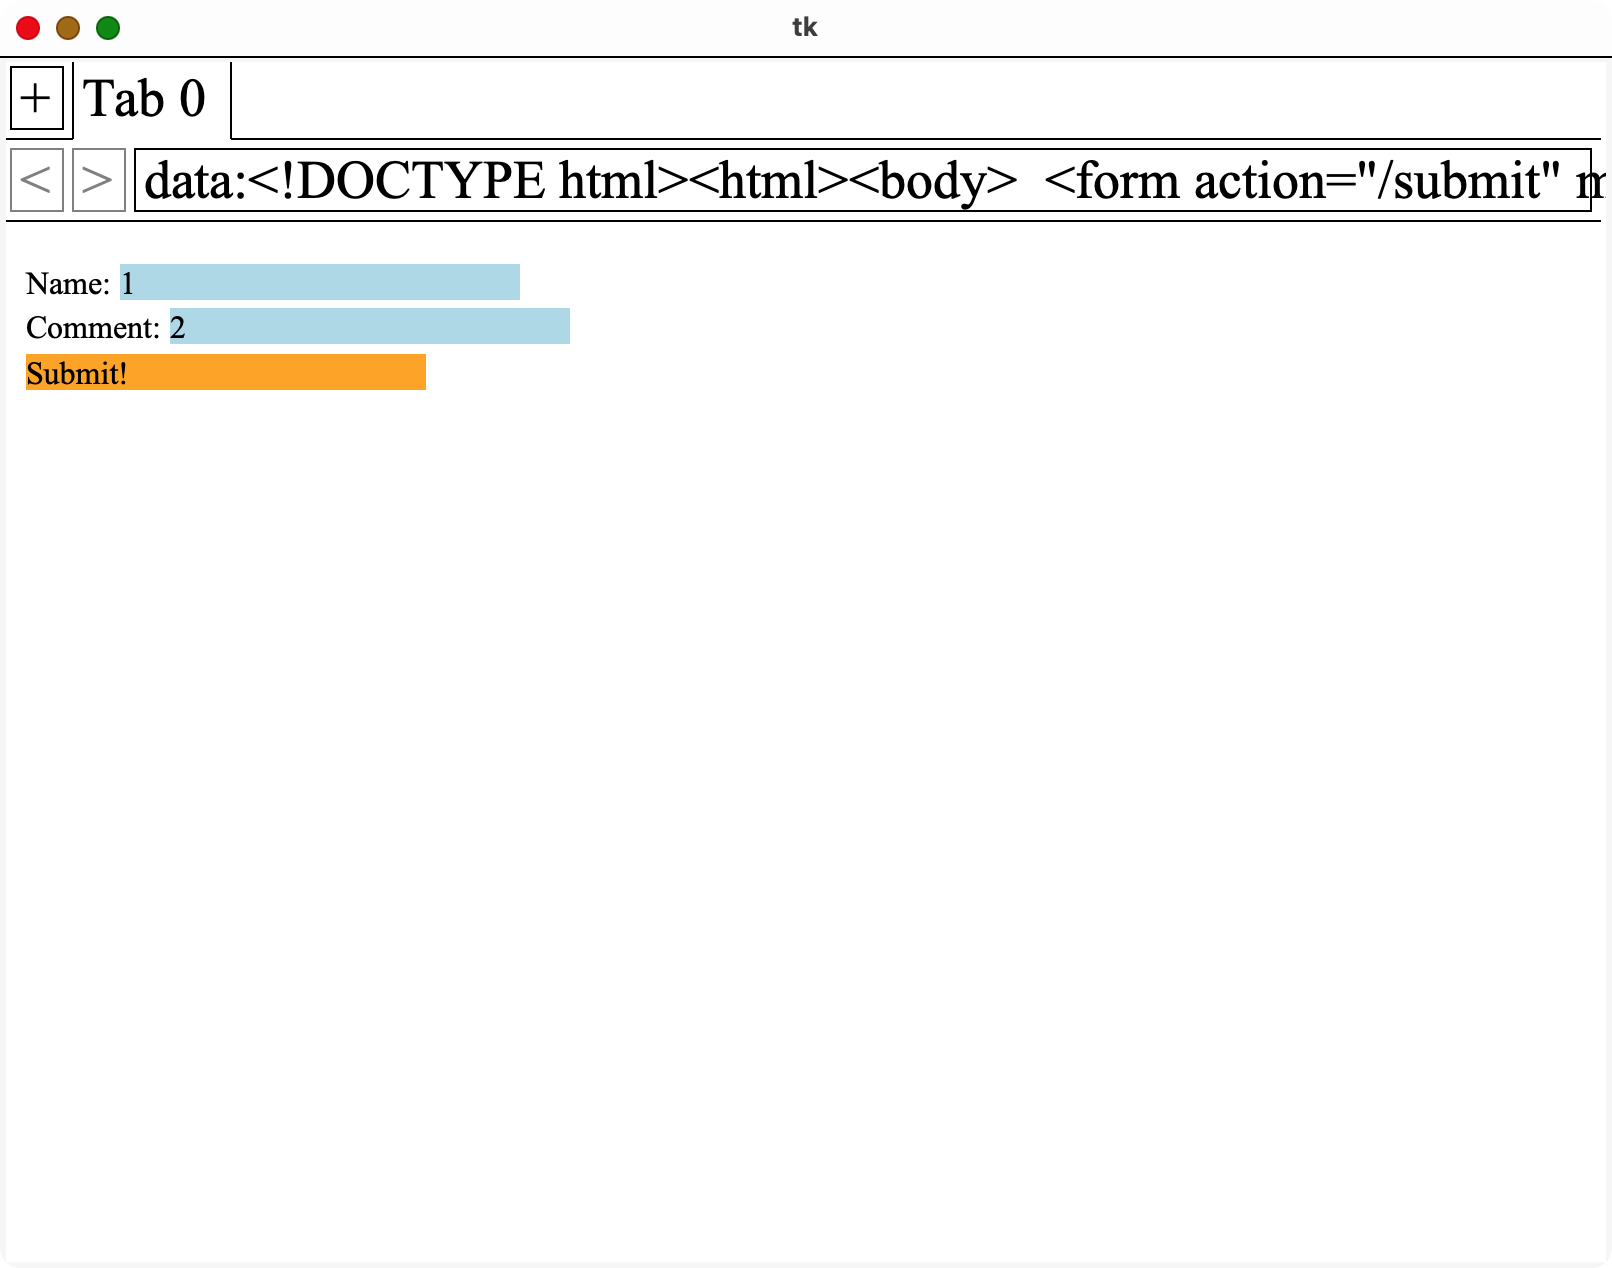

In [1]:
import time
import importlib
import browser.css
import browser.layout
import browser.browser

# 💡 모듈 핫 리로드
importlib.reload(browser.css)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser
from browser.url import URL
from browser.layout import InputLayout, DrawRect, DrawText
from browser.html import tree_to_list
from browser.tk_capture import display_tk_window

# 1. 책 8.1 & 8.2 절 예제 HTML (Figure 1 폼 요소 테스트)
html_content = """<!DOCTYPE html>
<html>
<body>
  <form action="/submit" method="post">
    <p>Name: <input name=name value=1></p>
    <p>Comment: <input name=comment value=2></p>
    <p><button>Submit!</button></p>
  </form>
</body>
</html>"""

# 2. 브라우저 생성 및 data: URL로 페이지 로드
browser = Browser()
browser.new_tab(URL("data:text/html," + html_content))

# 3. 레이아웃 트리 및 렌더링 명령 검증
tab = browser.active_tab
inputs = [obj for obj in tree_to_list(tab.document, []) if isinstance(obj, InputLayout)]
print(f"✅ 생성된 InputLayout 객체 수: {len(inputs)}개")
for inp in inputs:
    tag = inp.node.tag
    print(f" - [{tag:<6}] 위치: (x={inp.x:>3}, y={inp.y:>5.2f}) | 크기: {inp.width}px x {inp.height}px")

rects = [cmd for cmd in tab.display_list if isinstance(cmd, DrawRect)]
print(f"
✅ 렌더링된 사각형(DrawRect): {len(rects)}개")
for r in rects:
    w, h = int(r.rect.right - r.rect.left), int(r.rect.bottom - r.rect.top)
    print(f" - [{r.color:<10}] 위치: ({r.rect.left}, {r.rect.top}) | 크기: {w}px x {h}px")

texts = [cmd for cmd in tab.display_list if isinstance(cmd, DrawText)]
print(f"
✅ 렌더링된 텍스트(DrawText): {len(texts)}개")
for t in texts:
    print(f" - '{t.text}' (x={t.rect.left}, y={t.rect.top})")

# 4. 🌟 핵심: 창 준비 후 명시적 재드로잉(draw) 및 OS 버퍼 동기화
browser.draw()
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

# 5. 주피터 노트북에 브라우저 화면 인라인 출력
display_tk_window(browser.window, settle_seconds=0.5)


## 3. Interacting with Widgets


1. Name 입력창 초기 위치: (x=60, y=21.75) | 초기 value: '1'

2. Name 입력창 클릭 후:
 - Browser focus : content
 - Tab focus     : <input>
 - is_focused    : True
 - 클리어된 value: ''

3. 'Alice' 타이핑 후:
 - 업데이트된 value: 'Alice'

4. 렌더링 검증:
 - 'Alice' 텍스트 렌더링 여부: True (위치: x=60, y=21.75)
 - 텍스트 커서(DrawLine) 존재 여부: True (위치: x=95)


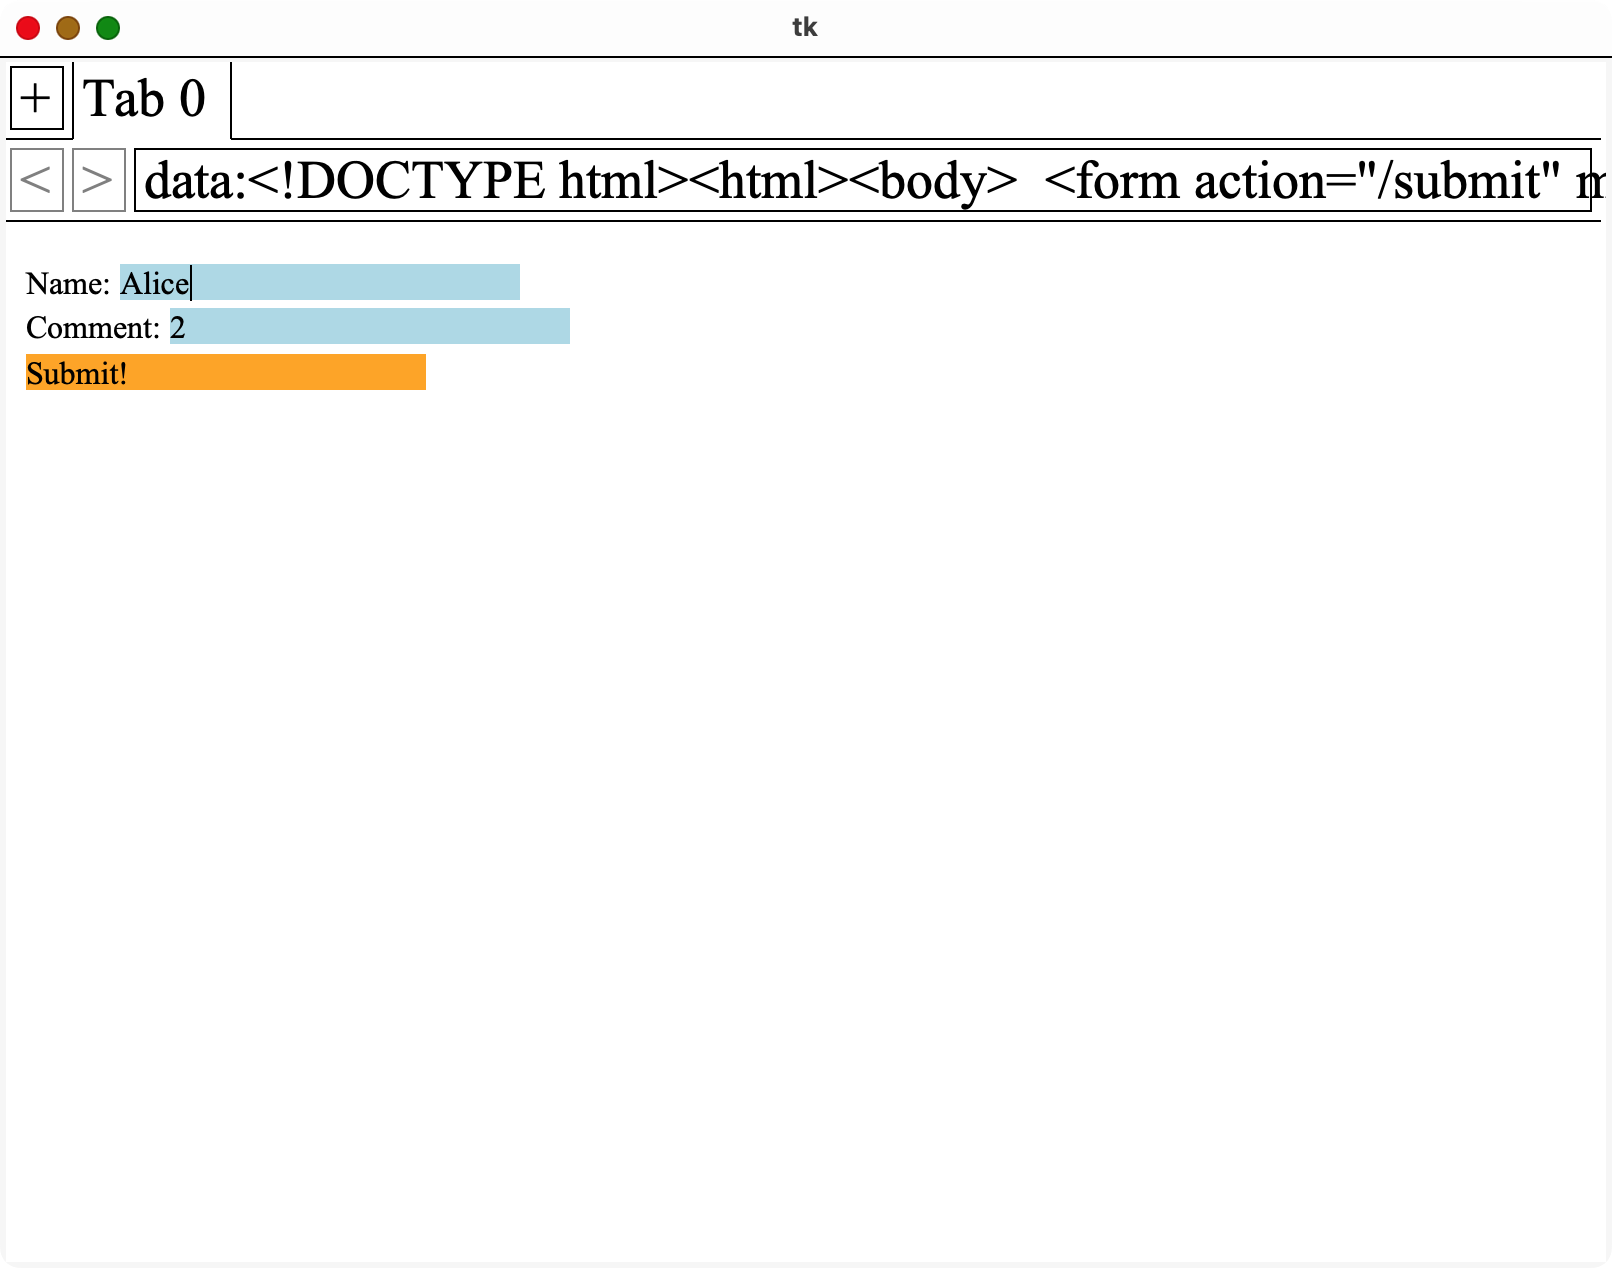

In [2]:
import time
import importlib
import browser.html
import browser.css
import browser.layout
import browser.browser

# 💡 모듈 핫 리로드
importlib.reload(browser.html)
importlib.reload(browser.css)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser
from browser.url import URL
from browser.layout import InputLayout, DrawRect, DrawText, DrawLine
from browser.html import tree_to_list
from browser.tk_capture import display_tk_window

# 1. 폼 HTML 로드
html_content = """<!DOCTYPE html>
<html>
<body>
  <form action="/submit" method="post">
    <p>Name: <input name=name value=1></p>
    <p>Comment: <input name=comment value=2></p>
    <p><button>Submit!</button></p>
  </form>
</body>
</html>"""

browser = Browser()
browser.new_tab(URL("data:text/html," + html_content))
tab = browser.active_tab

# 2. 첫 번째 input 위젯 좌표 찾기
inputs = [obj for obj in tree_to_list(tab.document, []) if isinstance(obj, InputLayout) and obj.node.tag == "input"]
name_input = inputs[0]
init_val = name_input.node.attributes.get("value")
print(f"1. Name 입력창 초기 위치: (x={name_input.x}, y={name_input.y}) | 초기 value: {init_val}")

# 3. 마우스 클릭 시뮬레이션: Name 입력창 클릭
class FakeMouseEvent:
    def __init__(self, x, y):
        self.x = x
        self.y = y

click_x = name_input.x + 10
click_y = browser.chrome.bottom + name_input.y + 5
browser.handle_click(FakeMouseEvent(click_x, click_y))

cleared_val = tab.focus.attributes.get("value")
print("\n2. Name 입력창 클릭 후:")
print(f" - Browser focus : {browser.focus}")
print(f" - Tab focus     : {tab.focus}")
print(f" - is_focused    : {tab.focus.is_focused}")
print(f" - 클리어된 value: {cleared_val}")

# 4. 키보드 입력 시뮬레이션: Alice 입력
class FakeKeyEvent:
    def __init__(self, char):
        self.char = char

for char in "Alice":
    browser.handle_key(FakeKeyEvent(char))

typed_val = tab.focus.attributes.get("value")
print("\n3. Alice 타이핑 후:")
print(f" - 업데이트된 value: {typed_val}")

# 5. 커서(DrawLine) 및 텍스트(DrawText) 렌더링 검증
inputs_updated = [obj for obj in tree_to_list(tab.document, []) if isinstance(obj, InputLayout) and obj.node.tag == "input"]
name_input_updated = inputs_updated[0]
cursors = [cmd for cmd in tab.display_list if isinstance(cmd, DrawLine) and cmd.color == "black" and cmd.rect.top == name_input_updated.y]
typed_texts = [cmd for cmd in tab.display_list if isinstance(cmd, DrawText) and cmd.text == "Alice"]
print("\n4. 렌더링 검증:")
print(f" - Alice 텍스트 렌더링 여부: {len(typed_texts) > 0} (위치: x={typed_texts[0].rect.left}, y={typed_texts[0].rect.top})")
print(f" - 텍스트 커서(DrawLine) 존재 여부: {len(cursors) > 0} (위치: x={cursors[0].rect.left})")

# 6. 브라우저 창 동기화 및 주피터 노트북에 화면 출력
browser.draw()
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

display_tk_window(browser.window, settle_seconds=0.5)


## 4. Submitting Forms

1. 폼 입력 완료:
 - Name    : 'Alice'
 - Comment : 'Hello_Server'

2. 폼 전송 완료:
 - 서버 수신 POST 페이로드: 'name=Alice&comment=Hello_Server'
 - 응답 후 활성 탭 URL    : http://127.0.0.1:8990/submit


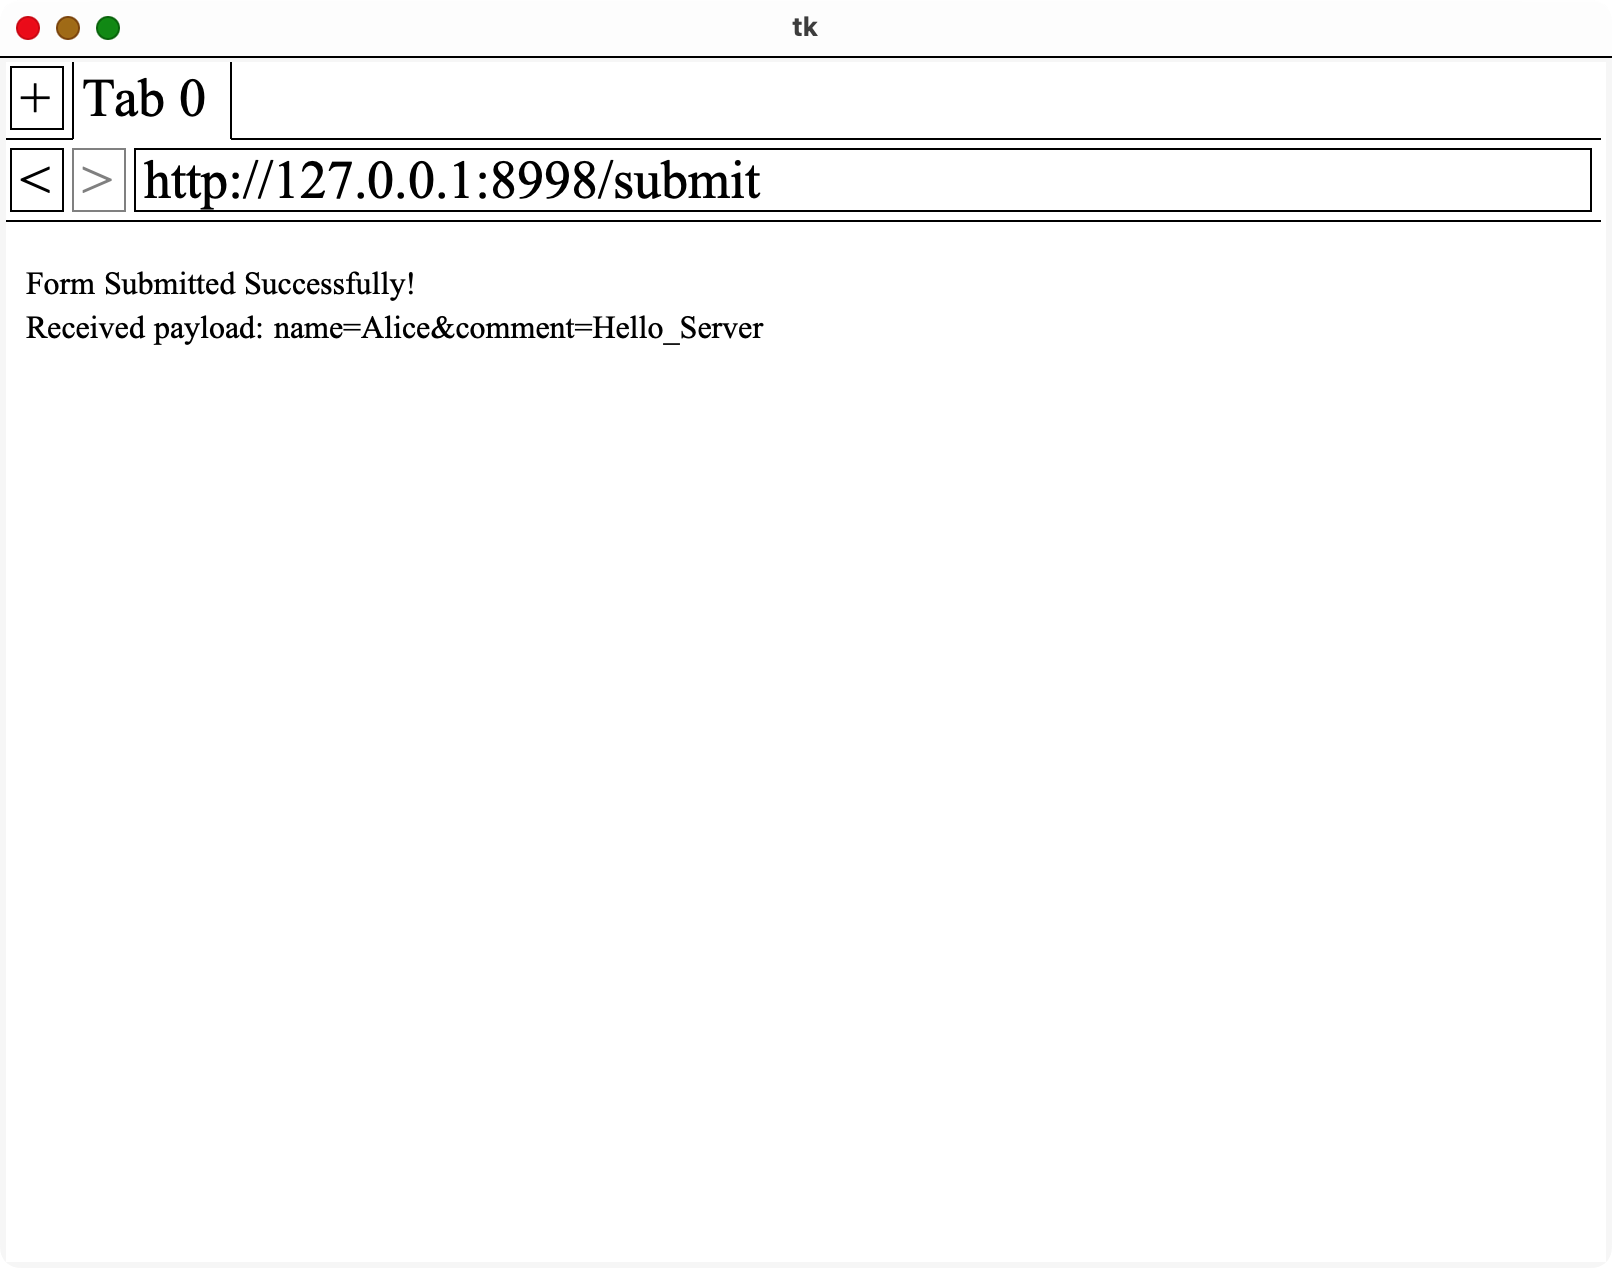

In [3]:
import time
import threading
import importlib
from http.server import HTTPServer, BaseHTTPRequestHandler

import browser.url
import browser.html
import browser.css
import browser.layout
import browser.browser

# 💡 모듈 핫 리로드
importlib.reload(browser.url)
importlib.reload(browser.html)
importlib.reload(browser.css)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser
from browser.url import URL
from browser.layout import InputLayout
from browser.html import tree_to_list
from browser.tk_capture import display_tk_window

# 1. 테스트용 로컬 HTTP 서버 실행 (GET 폼 제공 & POST 데이터 수신)
server_port = 8990
received_post = {}

class FormTestHandler(BaseHTTPRequestHandler):
    def do_GET(self):
        self.send_response(200)
        self.send_header("Content-Type", "text/html")
        self.end_headers()
        html = """<!DOCTYPE html>
<html>
<body>
  <form action="/submit" method="post">
    <p>Name: <input name=name value=1></p>
    <p>Comment: <input name=comment value=2></p>
    <p><button>Submit!</button></p>
  </form>
</body>
</html>"""
        self.wfile.write(html.encode("utf8"))

    def do_POST(self):
        content_length = int(self.headers.get("Content-Length", 0))
        post_body = self.rfile.read(content_length).decode("utf8")
        received_post["body"] = post_body
        received_post["headers"] = dict(self.headers)
        
        self.send_response(200)
        self.send_header("Content-Type", "text/html")
        self.end_headers()
        response_html = f"""<!DOCTYPE html>
<html>
<body>
  <h1>Form Submitted Successfully!</h1>
  <p>Received payload: {post_body}</p>
</body>
</html>"""
        self.wfile.write(response_html.encode("utf8"))

    def log_message(self, format, *args):
        pass

server = HTTPServer(("127.0.0.1", server_port), FormTestHandler)
server_thread = threading.Thread(target=server.serve_forever, daemon=True)
server_thread.start()
time.sleep(0.1)

try:
    # 2. 브라우저로 폼 페이지 접속
    browser = Browser()
    browser.new_tab(URL(f"http://127.0.0.1:{server_port}/"))
    tab = browser.active_tab

    inputs = [obj for obj in tree_to_list(tab.document, []) if isinstance(obj, InputLayout)]
    name_inp, comment_inp, btn = inputs[0], inputs[1], inputs[2]

    class FakeMouseEvent:
        def __init__(self, x, y):
            self.x, self.y = x, y

    class FakeKeyEvent:
        def __init__(self, char):
            self.char = char

    # 3. Name 입력창 클릭 후 'Alice' 입력
    browser.handle_click(FakeMouseEvent(name_inp.x + 10, browser.chrome.bottom + name_inp.y + 5))
    for c in "Alice":
        browser.handle_key(FakeKeyEvent(c))

    # 4. Comment 입력창 클릭 후 'Hello_Server' 입력
    browser.handle_click(FakeMouseEvent(comment_inp.x + 10, browser.chrome.bottom + comment_inp.y + 5))
    for c in "Hello_Server":
        browser.handle_key(FakeKeyEvent(c))

    print("1. 폼 입력 완료:")
    print(f" - Name    : '{name_inp.node.attributes.get('value')}'")
    print(f" - Comment : '{comment_inp.node.attributes.get('value')}'")

    # 5. Submit 버튼 클릭 -> 폼 전송 트리거
    browser.handle_click(FakeMouseEvent(btn.x + 10, browser.chrome.bottom + btn.y + 5))

    print("\n2. 폼 전송 완료:")
    print(f" - 서버 수신 POST 페이로드: '{received_post.get('body')}'")
    print(f" - 응답 후 활성 탭 URL    : {browser.active_tab.url}")

    # 6. 브라우저 창 갱신 및 주피터 노트북에 결과 화면 출력
    browser.draw()
    for _ in range(10):
        browser.window.update_idletasks()
        browser.window.update()
        time.sleep(0.05)

    display_tk_window(browser.window, settle_seconds=0.5)
finally:
    server.shutdown()
    server.server_close()


## 5. How web apps work

웹 애플리케이션은 **브라우저(클라이언트)**와 **웹 서버** 간의 명확한 역할 분담과 HTTP 요청-응답 주기를 기반으로 작동합니다.

- **상태 관리의 주체 (Server)**: 데이터베이스나 인메모리 저장소를 통해 애플리케이션의 핵심 데이터(상태)를 보관하고 업데이트합니다.
- **사용자 인터페이스 (Client)**: 폼 및 UI 위젯을 렌더링하고, 사용자의 인터랙션(입력, 클릭)을 감지하여 HTTP 요청(`GET`, `POST`)으로 서버에 전달합니다.
- **요청-응답 사이클**:
  1. 브라우저가 `GET` 요청으로 초기 폼 페이지를 로드
  2. 사용자가 폼을 작성하고 제출하면 브라우저가 `POST` 요청(데이터 페이로드 포함)을 서버로 전송
  3. 서버가 데이터를 처리한 후 새로운 HTML 페이지로 응답하여 브라우저 화면이 갱신됨


## 6. Receiving POST Requests

웹 서버는 브라우저와 완전히 독립된 별개의 프로그램입니다. 요청-응답 주기의 반대편인 **웹 서버(`src/server/server.py`)** 측에서 TCP 소켓을 직접 열고, 들어오는 HTTP `POST` 요청을 수신 및 파싱하여 응답하는 과정을 구현합니다.

### 핵심 구현 내용 (`src/server/server.py`)
1. **소켓 바인딩 및 리슨 (`run_server`)**
   - `socket.socket(socket.AF_INET, socket.SOCK_STREAM)`으로 TCP 소켓 생성
   - `setsockopt(..., SO_REUSEADDR, 1)`: 포트 바인딩 충돌 방지
   - `s.bind(('', port))` 및 `s.listen()`: 클라이언트 접속 대기
2. **요청 파싱 (`handle_connection`)**
   - **Request Line**: `req.readline()`으로 `METHOD URL VERSION` 분리
   - **Headers**: 빈 줄(`\r\n`)이 나올 때까지 줄 단위로 읽어 헤더 딕셔너리 구축
   - **Body (Content-Length)**: 서버는 클라이언트가 소켓을 닫지 않으므로 `Content-Length` 헤더에 명시된 바이트 수만큼만 정확히 소켓에서 읽음 (`req.read(length)`)
3. **응답 전송**
   - `do_request(method, url, headers, body)`를 호출하여 상태 코드와 HTML 본문 생성
   - `HTTP/1.0 {status}\r\nContent-Length: {len}\r\n\r\n{body}` 포맷으로 클라이언트에 전송 후 소켓 종료


1. 서버의 GET 요청 처리 결과:
 - 요청 URL : http://127.0.0.1:8996/welcome
 - 렌더링된 텍스트: Received GET request for /welcome

2. 서버의 POST 요청 처리 결과:
 - 요청 URL : http://127.0.0.1:8996/submit-comment
 - 렌더링된 텍스트: Received POST request for /submit-comment


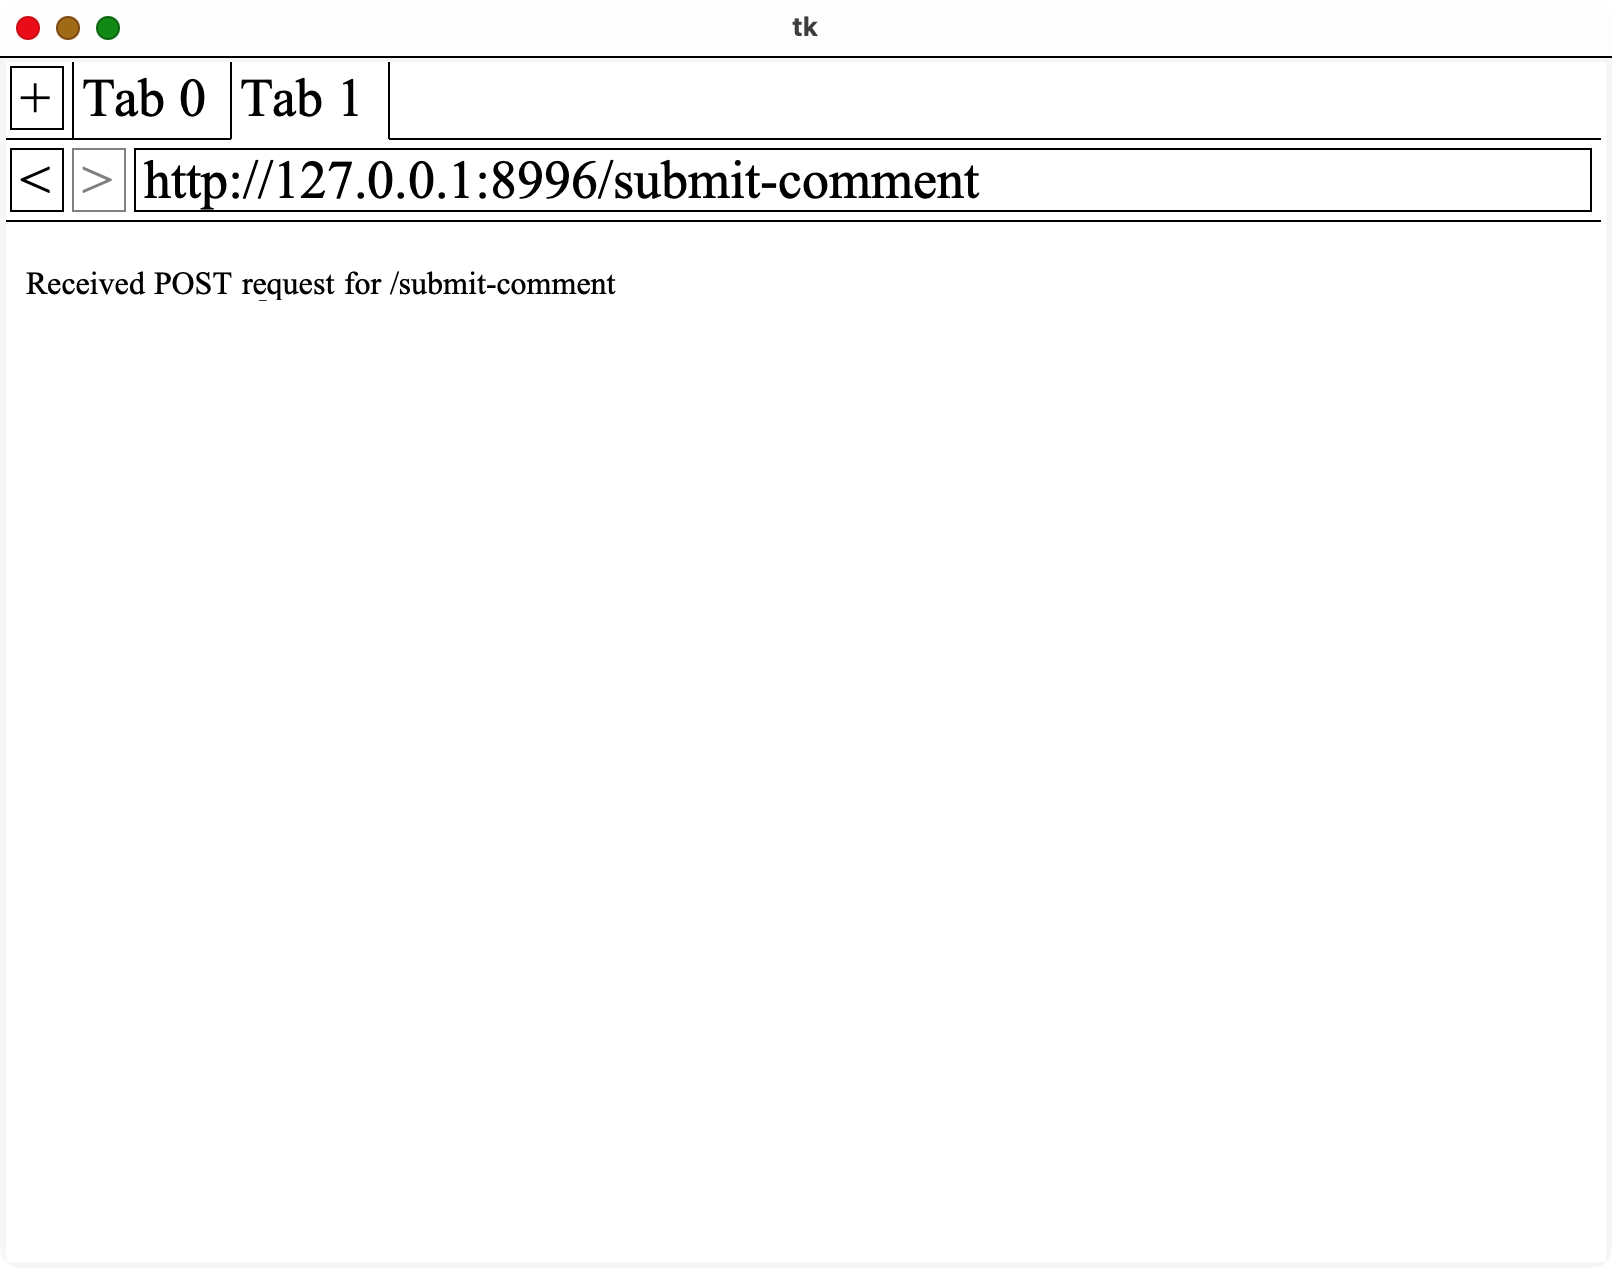

In [4]:
import time
import threading
import importlib

import browser.url
import browser.browser
import server.server

# 💡 모듈 핫 리로드
importlib.reload(browser.url)
importlib.reload(browser.browser)
importlib.reload(server.server)

from server import run_server
from browser.browser import Browser
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 독립 웹 서버(server 패키지) 백그라운드 스레드로 실행
# 💡 8.6 절의 요청 수신 검증용 임시 do_request 핸들러 설정
server.server.do_request = lambda method, url, headers, body: ('200 OK', f"<!doctype html><p>Received {method} request for {url}</p>")
server_port = 8996
stop_event = threading.Event()
server_thread = threading.Thread(target=run_server, args=(server_port, stop_event), daemon=True)
server_thread.start()
time.sleep(0.1)

try:
    browser = Browser()

    # 2. GET 요청 테스트: /welcome 접속
    browser.new_tab(URL(f"http://127.0.0.1:{server_port}/welcome"))
    print("1. 서버의 GET 요청 처리 결과:")
    print(f" - 요청 URL : {browser.active_tab.url}")
    get_texts = [cmd.text for cmd in browser.active_tab.display_list if hasattr(cmd, 'text')]
    print(f" - 렌더링된 텍스트: {' '.join(get_texts)}")

    # 3. POST 요청 테스트: /submit-comment에 payload 전송
    browser.new_tab(URL(f"http://127.0.0.1:{server_port}/submit-comment"))
    browser.active_tab.load(
        URL(f"http://127.0.0.1:{server_port}/submit-comment"),
        payload="name=Alice&comment=Nice_Post"
    )
    print("\n2. 서버의 POST 요청 처리 결과:")
    print(f" - 요청 URL : {browser.active_tab.url}")
    post_texts = [cmd.text for cmd in browser.active_tab.display_list if hasattr(cmd, 'text')]
    print(f" - 렌더링된 텍스트: {' '.join(post_texts)}")

    # 4. 브라우저 화면 갱신 및 주피터 노트북에 화면 출력
    browser.draw()
    for _ in range(10):
        browser.window.update_idletasks()
        browser.window.update()
        time.sleep(0.05)

    display_tk_window(browser.window, settle_seconds=0.5)
finally:
    stop_event.set()
    server_thread.join(timeout=1.0)


## 7. Generating Web Pages


1. 초기 방명록 페이지 로드:
 - 접속 URL : http://127.0.0.1:8997/
 - 렌더링 텍스트: Pavel was here  Sign the book!
 - 포커스된 위젯: <input name=guest>
 - 입력된 값: 'Alice was here too!'

2. 방명록 등록(POST /add) 후 브라우저 갱신 결과:
 - 갱신 URL : http://127.0.0.1:8997/add
 - 렌더링 텍스트: Pavel was here Alice was here too!  Sign the book!
 - 서버 ENTRIES 상태: ['Pavel was here', 'Alice was here too!']


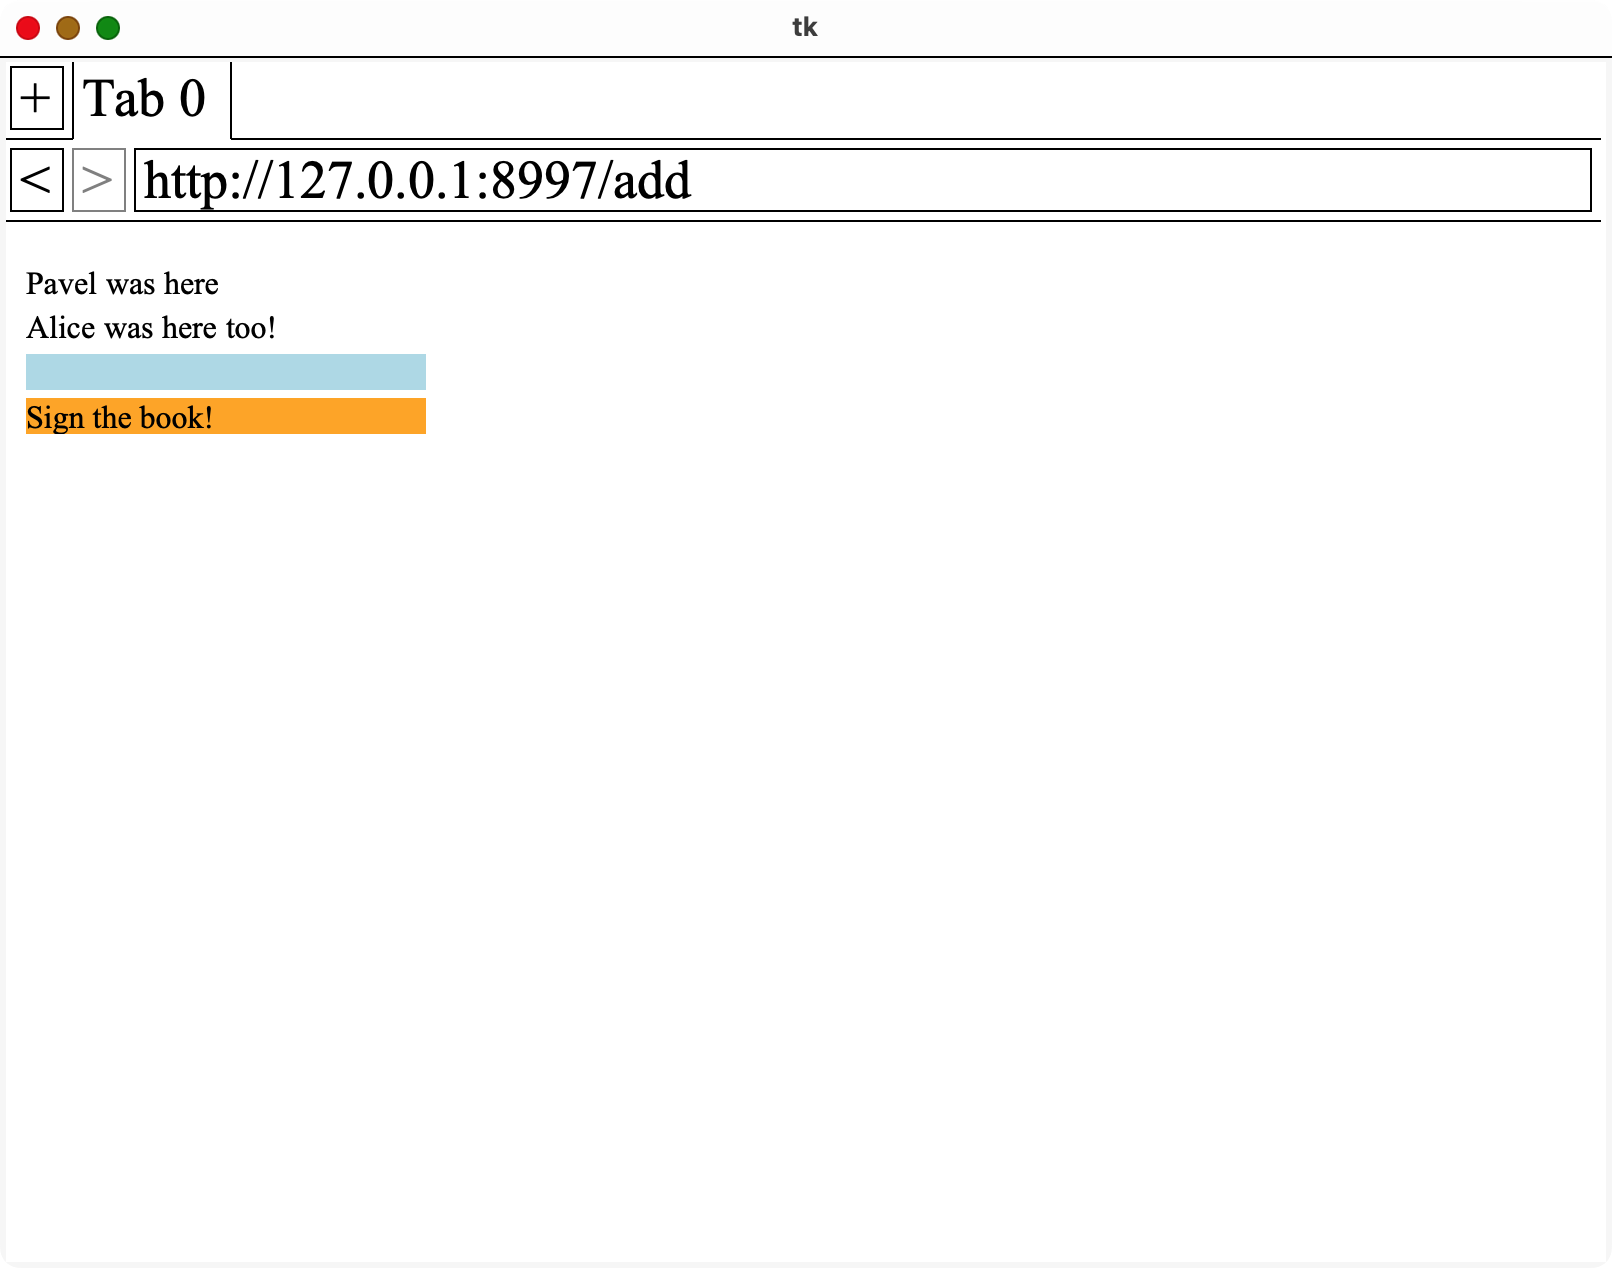

In [6]:
import time
import threading
import importlib

import browser.url
import browser.browser
import server.server

# 💡 모듈 핫 리로드 (최신 8.7 방명록 서버 로직 반영)
importlib.reload(browser.url)
importlib.reload(browser.browser)
importlib.reload(server.server)

from server import run_server, ENTRIES
from browser.browser import Browser
from browser.url import URL
from browser.layout import InputLayout
from browser.tk_capture import display_tk_window

# 1. 포트 설정 및 방명록 초기 상태 준비
server_port = 8997
ENTRIES.clear()
ENTRIES.append('Pavel was here')

stop_event = threading.Event()
server_thread = threading.Thread(target=run_server, args=(server_port, stop_event), daemon=True)
server_thread.start()
time.sleep(0.1)

try:
    browser = Browser()

    # 2. 방명록 홈(/) 접속 (GET 요청)
    url = URL(f"http://127.0.0.1:{server_port}/")
    browser.new_tab(url)
    tab = browser.active_tab

    print("1. 초기 방명록 페이지 로드:")
    print(f" - 접속 URL : {tab.url}")
    texts = [cmd.text for cmd in tab.display_list if hasattr(cmd, 'text')]
    print(f" - 렌더링 텍스트: {' '.join(texts)}")

    # 3. 레이아웃 트리에서 input 위젯 및 button 위젯 탐색
    def find_inputs(layout):
        res = []
        if isinstance(layout, InputLayout):
            res.append(layout)
        for child in layout.children:
            res.extend(find_inputs(child))
        return res

    inputs = find_inputs(tab.document)
    text_input = [inp for inp in inputs if inp.node.tag == "input"][0]
    button = [inp for inp in inputs if inp.node.tag == "button"][0]

    class FakeEvent:
        def __init__(self, x, y, char=""):
            self.x = x
            self.y = y
            self.char = char

    # 4. input 위젯 클릭하여 포커스 지정
    click_x = text_input.x + 5
    click_y = text_input.y + browser.chrome.bottom + 5 - tab.scroll
    browser.handle_click(FakeEvent(click_x, click_y))
    print(f" - 포커스된 위젯: <{tab.focus.tag} name={tab.focus.attributes.get('name')}>")

    # 5. 새 방명록 서명 입력 ('Alice was here too!')
    new_entry_text = "Alice was here too!"
    for ch in new_entry_text:
        browser.handle_key(FakeEvent(0, 0, char=ch))
    print(f" - 입력된 값: '{tab.focus.attributes.get('value')}'")

    # 6. 'Sign the book!' 버튼 클릭 -> 폼 제출 (POST /add 전송)
    btn_x = button.x + 5
    btn_y = button.y + browser.chrome.bottom + 5 - tab.scroll
    browser.handle_click(FakeEvent(btn_x, btn_y))

    time.sleep(0.2)
    new_tab = browser.active_tab

    print("\n2. 방명록 등록(POST /add) 후 브라우저 갱신 결과:")
    print(f" - 갱신 URL : {new_tab.url}")
    new_texts = [cmd.text for cmd in new_tab.display_list if hasattr(cmd, 'text')]
    print(f" - 렌더링 텍스트: {' '.join(new_texts)}")
    print(f" - 서버 ENTRIES 상태: {ENTRIES}")

    # 7. GUI 화면 렌더링 및 창 캡처 출력
    browser.draw()
    for _ in range(10):
        browser.window.update_idletasks()
        browser.window.update()
        time.sleep(0.05)

    display_tk_window(browser.window, settle_seconds=0.5)
finally:
    stop_event.set()
    server_thread.join(timeout=1.0)


## 10. Exercises

### 8-1 *Enter key*.

In most browsers, if you hit the “Enter” or “Return” key while inside a text entry, that submits the form that the text entry was in. Add this feature to your browser.


1. 초기 방명록 페이지 로드:
 - 접속 URL : http://127.0.0.1:8998/
 - 렌더링 텍스트: Pavel was here  Sign the book!
 - 포커스된 위젯: <input name=guest>
 - 입력된 값: 'Bob submitted via Enter!'

2. 엔터 키(Enter) 입력으로 폼 제출 실행:
 - 갱신 URL : http://127.0.0.1:8998/add
 - 렌더링 텍스트: Pavel was here Bob submitted via Enter!  Sign the book!
 - 서버 ENTRIES 상태: ['Pavel was here', 'Bob submitted via Enter!']


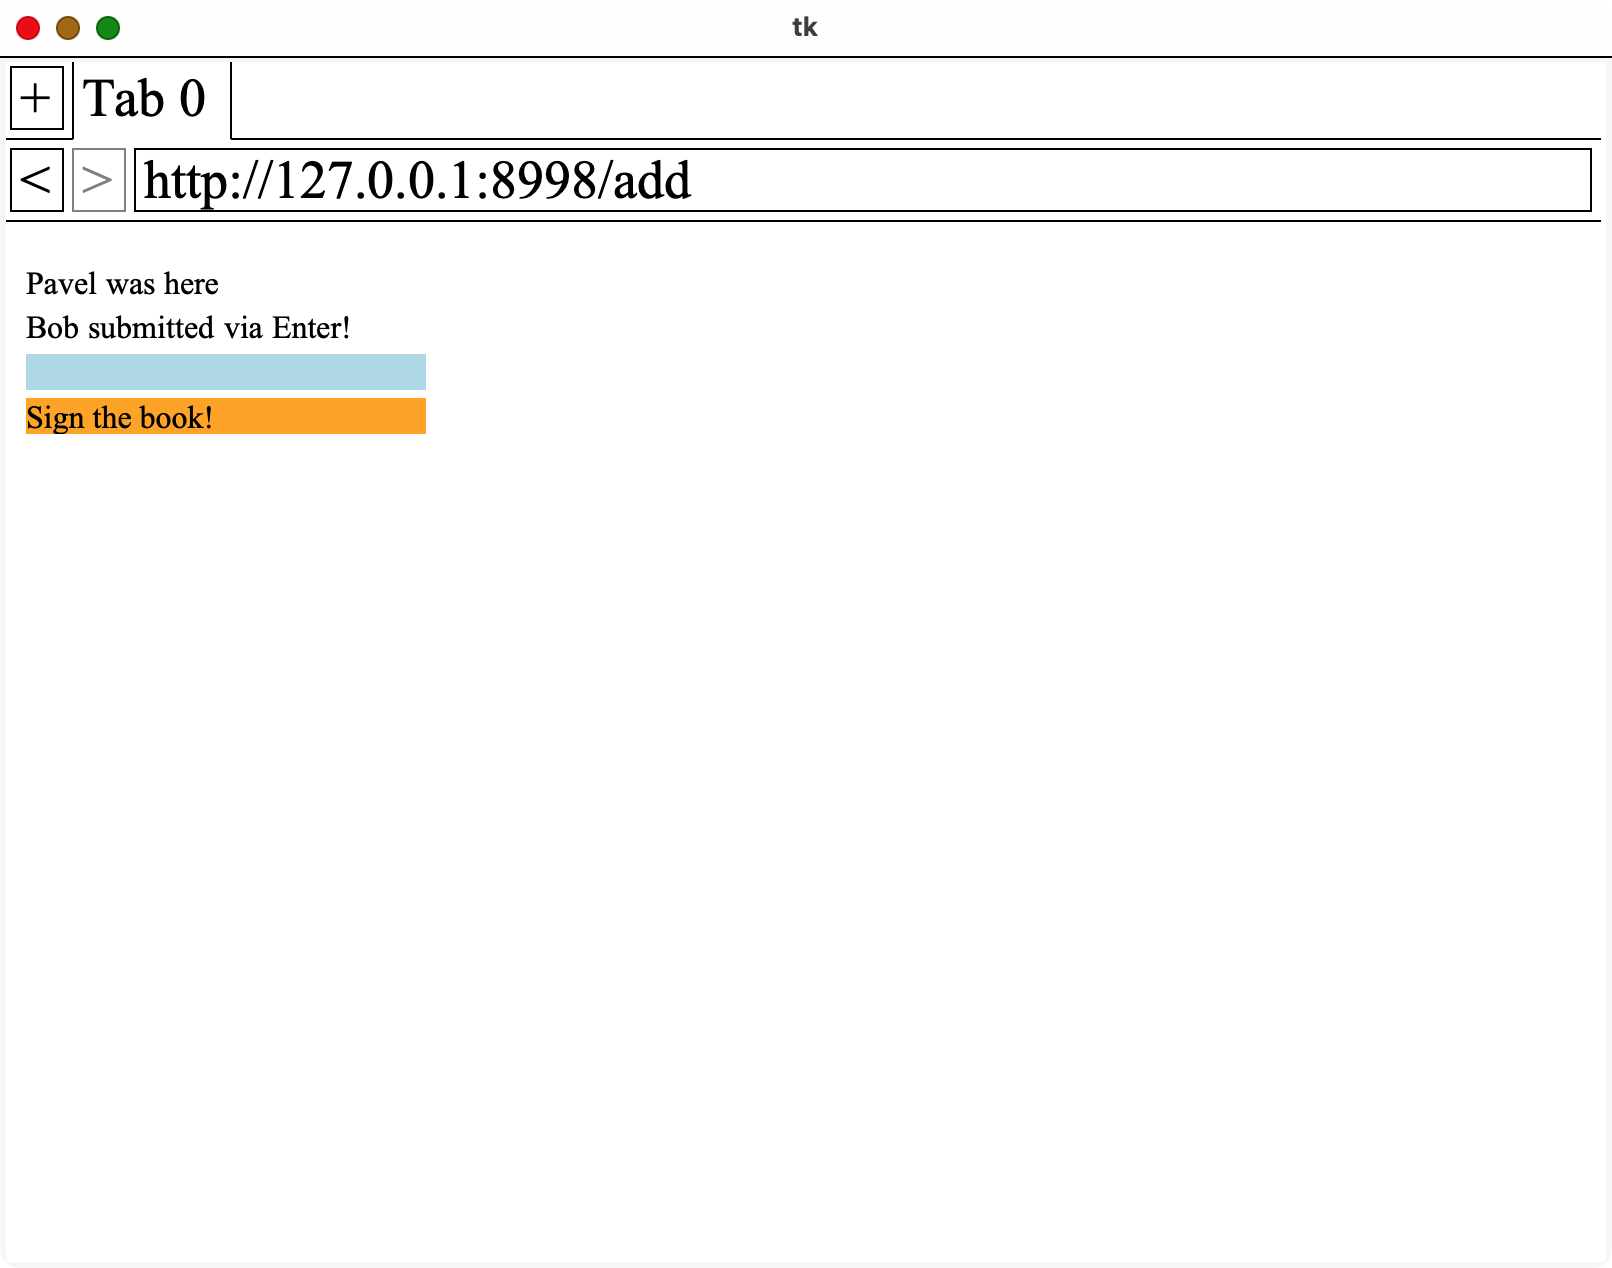

In [7]:
import time
import threading
import importlib

import browser.url
import browser.browser
import server.server

# 💡 모듈 핫 리로드 (최신 Enter 키 처리 로직 반영)
importlib.reload(browser.url)
importlib.reload(browser.browser)
importlib.reload(server.server)

from server import run_server, ENTRIES
from browser.browser import Browser
from browser.url import URL
from browser.layout import InputLayout
from browser.tk_capture import display_tk_window

# 1. 포트 설정 및 방명록 초기 상태 준비
server_port = 8998
ENTRIES.clear()
ENTRIES.append('Pavel was here')

stop_event = threading.Event()
server_thread = threading.Thread(target=run_server, args=(server_port, stop_event), daemon=True)
server_thread.start()
time.sleep(0.1)

try:
    browser = Browser()

    # 2. 방명록 홈(/) 접속
    url = URL(f"http://127.0.0.1:{server_port}/")
    browser.new_tab(url)
    tab = browser.active_tab

    print("1. 초기 방명록 페이지 로드:")
    print(f" - 접속 URL : {tab.url}")
    texts = [cmd.text for cmd in tab.display_list if hasattr(cmd, 'text')]
    print(f" - 렌더링 텍스트: {' '.join(texts)}")

    # 3. 레이아웃 트리에서 input 위젯 탐색
    def find_inputs(layout):
        res = []
        if isinstance(layout, InputLayout):
            res.append(layout)
        for child in layout.children:
            res.extend(find_inputs(child))
        return res

    inputs = find_inputs(tab.document)
    text_input = [inp for inp in inputs if inp.node.tag == "input"][0]

    class FakeEvent:
        def __init__(self, x=0, y=0, char=""):
            self.x = x
            self.y = y
            self.char = char

    # 4. input 위젯 클릭하여 포커스 활성화
    click_x = text_input.x + 5
    click_y = text_input.y + browser.chrome.bottom + 5 - tab.scroll
    browser.handle_click(FakeEvent(click_x, click_y))
    print(f" - 포커스된 위젯: <{tab.focus.tag} name={tab.focus.attributes.get('name')}>")

    # 5. 새 방명록 메시지 타이핑 입력
    new_entry_text = "Bob submitted via Enter!"
    for ch in new_entry_text:
        browser.handle_key(FakeEvent(0, 0, char=ch))
    print(f" - 입력된 값: '{tab.focus.attributes.get('value')}'")

    # 6. 버튼을 클릭하지 않고 'Enter' 키를 입력하여 폼 제출 트리거
    print("\n2. 엔터 키(Enter) 입력으로 폼 제출 실행:")
    browser.handle_enter(FakeEvent())

    time.sleep(0.2)
    new_tab = browser.active_tab

    print(f" - 갱신 URL : {new_tab.url}")
    new_texts = [cmd.text for cmd in new_tab.display_list if hasattr(cmd, 'text')]
    print(f" - 렌더링 텍스트: {' '.join(new_texts)}")
    print(f" - 서버 ENTRIES 상태: {ENTRIES}")

    # 7. GUI 화면 렌더링 및 캡처 출력
    browser.draw()
    for _ in range(10):
        browser.window.update_idletasks()
        browser.window.update()
        time.sleep(0.05)

    display_tk_window(browser.window, settle_seconds=0.5)
finally:
    stop_event.set()
    server_thread.join(timeout=1.0)
